LOG will be here...

In [33]:
# ---  Imports & plotting defaults ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

from typing import Iterable
from scipy.fft import dct, idct
from sklearn.neighbors import LocalOutlierFactor
from statsmodels.tsa.seasonal import STL
from scipy.signal import spectrogram

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True

# Optional: pretty display of wide DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)


In [27]:
# --- Price areas → city centerpoints DataFrame ---

# This maps the five NO price areas to representative cities and their lat/lon.
# Coordinates are approximate city centers; good enough for ERA5 grid sampling.

PRICE_AREAS = [
    {"area": "NO1", "city": "Oslo",         "lat": 59.9139,  "lon": 10.7522},
    {"area": "NO2", "city": "Kristiansand", "lat": 58.1467,  "lon": 7.9956},
    {"area": "NO3", "city": "Trondheim",    "lat": 63.4305,  "lon": 10.3951},
    {"area": "NO4", "city": "Tromsø",       "lat": 69.6492,  "lon": 18.9553},
    {"area": "NO5", "city": "Bergen",       "lat": 60.39299, "lon": 5.32415},
]

locations_df = pd.DataFrame(PRICE_AREAS)[["area", "city", "lon", "lat"]]
locations_df

,area,city,lon,lat
0,NO1,Oslo,10.75220,59.91390
1,NO2,Kristiansand,7.99560,58.14670
2,NO3,Trondheim,10.39510,63.43050
3,NO4,Tromsø,18.95530,69.64920
4,NO5,Bergen,5.32415,60.39299


In [28]:
# Function to download one year's worth of hourly ERA5 reanalysis for a single (lat, lon).
# Adjust 'hourly_vars' to match the variables you used in Part 1 (CSV).
OPEN_METEO_BASE = "https://archive-api.open-meteo.com/v1/era5"

def get_era5_hourly(
    lat: float,
    lon: float,
    year: int,
    hourly_vars: Iterable[str] = (
        "temperature_2m",
        "relative_humidity_2m",
        "dew_point_2m",
        "apparent_temperature",
        "surface_pressure",
        "precipitation",
        "rain",
        "snowfall",
        "cloud_cover",
        "wind_speed_10m",
        "wind_direction_10m",
        "shortwave_radiation",
    ),
    timezone: str = "Europe/Oslo",
) -> pd.DataFrame:
    """
    Download hourly ERA5 reanalysis for a given (lat, lon) and year.
    Returns a DataFrame with 'timestamp' and the requested variables.
    """
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": f"{year}-01-01",
        "end_date": f"{year}-12-31",
        "hourly": ",".join(hourly_vars),
        "models": "era5",
        "timezone": timezone,  # Makes times localized to Europe/Oslo in the payload
    }
    r = requests.get(OPEN_METEO_BASE, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    hourly = data.get("hourly", {})
    if not hourly:
        raise ValueError("No 'hourly' payload returned. Check parameters/variables.")
    df = pd.DataFrame(hourly)
    df = df.rename(columns={"time": "timestamp"})
    # API returns local time strings (Europe/Oslo) since we requested that timezone
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df

# --- Example: Bergen 2019 ---
bergen = next(x for x in PRICE_AREAS if x["city"] == "Bergen")
wx2019_bergen = get_era5_hourly(bergen["lat"], bergen["lon"], 2019)
wx2019_bergen.head()


,timestamp,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,surface_pressure,precipitation,rain,snowfall,cloud_cover,wind_speed_10m,wind_direction_10m,shortwave_radiation
0,2019-01-01 00:00:00,6.7,81,3.7,-1.0,998.1,0.4,0.4,0.0,91,42.7,261,0.0
1,2019-01-01 01:00:00,6.6,82,3.7,-1.9,997.6,0.5,0.5,0.0,97,48.0,278,0.0
2,2019-01-01 02:00:00,6.8,82,3.9,-1.7,996.5,0.9,0.9,0.0,94,48.6,296,0.0
3,2019-01-01 03:00:00,6.8,83,4.1,-2.2,997.7,0.7,0.7,0.0,97,52.6,310,0.0
4,2019-01-01 04:00:00,6.6,82,3.8,-3.0,999.4,0.6,0.6,0.0,90,55.8,314,0.0


,n,n_outliers,pct_outliers,dct_cutoff,n_sigma,median_SATV,sigma_robust,upper_bound,lower_bound
0,8760,298,3.401826,0.025,2.5,-0.03106,1.264694,3.130676,-3.192796


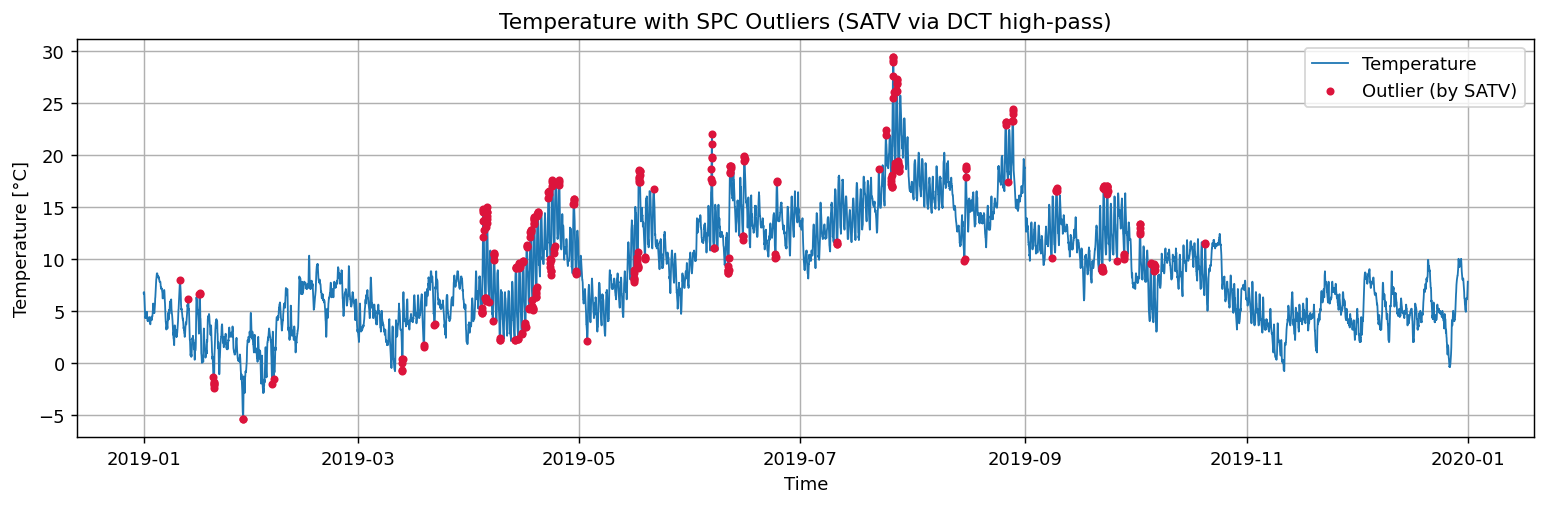

In [30]:
# remove seasonal/low-frequency components from temperature via DCT high-pass,
# obtaining Seasonally Adjusted Temperature Variations (SATV).
# Then compute robust SPC limits using median ± n_sigma * (1.4826 * MAD).
# plot raw temperature and only mark the timestamps flagged by SATV.

def spc_outliers_temperature(
    df: pd.DataFrame,
    time_col: str = "timestamp",
    temp_col: str = "temperature_2m",
    dct_cutoff: float = 0.025,   # fraction of lowest DCT freqs to zero out (0..1)
    n_sigma: float = 2.5,       # robust sigma multiplier
):
    """
    Returns (fig, outliers_df, summary_df).
    """
    ts = df[[time_col, temp_col]].dropna().copy()
    x = ts[temp_col].to_numpy(float)

    # DCT-II forward transform
    X = dct(x, type=2, norm="ortho")

    # Remove low-frequency components
    k = max(1, int(len(X) * dct_cutoff))
    X_hp = X.copy()
    X_hp[:k] = 0.0

    # Inverse transform to obtain SATV
    satv = idct(X_hp, type=2, norm="ortho")
    satv_s = pd.Series(satv, index=ts.index, name="SATV")  # align to rows

    # Robust SPC bounds from SATV
    med = float(np.median(satv))
    mad = float(np.median(np.abs(satv - med)))
    sigma = 1.4826 * mad if mad > 0 else float(np.std(satv))
    upper = med + n_sigma * sigma
    lower = med - n_sigma * sigma

    # Outliers by SATV
    is_out = (satv_s > upper) | (satv_s < lower)  # pandas Series[bool]
    out_df = ts.loc[is_out].assign(SATV=satv_s.loc[is_out])

    # Plot raw temperature; highlight SATV-defined outliers
    fig, ax = plt.subplots()
    ax.plot(ts[time_col], ts[temp_col], linewidth=1.0, label="Temperature")
    ax.scatter(out_df[time_col], out_df[temp_col],
               s=12, color="crimson", label="Outlier (by SATV)", zorder=3)
    ax.set_title("Temperature with SPC Outliers (SATV via DCT high-pass)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Temperature [°C]")
    ax.legend(loc="best")
    fig.tight_layout()

    summary = {
        "n": int(len(ts)),
        "n_outliers": int(is_out.sum()),
        "pct_outliers": float(is_out.mean() * 100.0),
        "dct_cutoff": float(dct_cutoff),
        "n_sigma": float(n_sigma),
        "median_SATV": med,
        "sigma_robust": sigma,
        "upper_bound": upper,
        "lower_bound": lower,
    }
    return fig, out_df, pd.DataFrame([summary])


# --- Test on Bergen 2019 ---
fig_spc, out_points, out_summary = spc_outliers_temperature(wx2019_bergen)
display(out_summary)
plt.show()


,n,n_anomalies,pct_anomalies,contamination
0,8760,86,0.981735,0.01


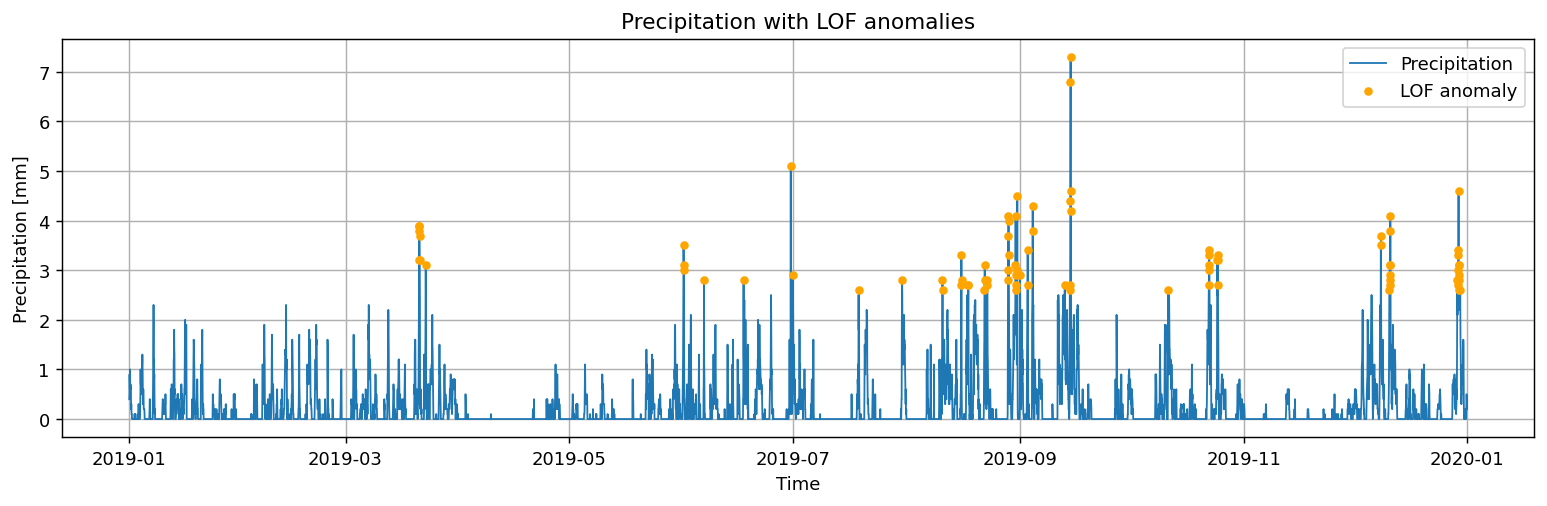

In [31]:
# Local Outlier Factor on the univariate precipitation series.
# 'contamination' controls the proportion flagged as anomalies; default 1% per assignment.

def lof_precip_anomalies(
    df: pd.DataFrame,
    time_col: str = "timestamp",
    precip_col: str = "precipitation",
    contamination: float = 0.01,
):
    """
    Return (fig, anomalies_df, summary_df).
    """
    sub = df[[time_col, precip_col]].dropna().copy()
    y = sub[precip_col].to_numpy(float).reshape(-1, 1)

    lof = LocalOutlierFactor(n_neighbors=35, contamination=contamination)
    labels = lof.fit_predict(y)  # -1 = anomaly; 1 = inlier
    scores = -lof.negative_outlier_factor_
    sub["lof_score"] = scores

    anoms = sub.loc[labels == -1]

    # Plot
    fig, ax = plt.subplots()
    ax.plot(sub[time_col], sub[precip_col], linewidth=1.0, label="Precipitation")
    ax.scatter(anoms[time_col], anoms[precip_col],
               s=14, color="orange", label="LOF anomaly", zorder=3)
    ax.set_title("Precipitation with LOF anomalies")
    ax.set_xlabel("Time")
    ax.set_ylabel("Precipitation [mm]")
    ax.legend(loc="best")
    fig.tight_layout()

    summary = {
        "n": int(len(sub)),
        "n_anomalies": int(len(anoms)),
        "pct_anomalies": float(100 * len(anoms) / max(1, len(sub))),
        "contamination": float(contamination),
    }
    return fig, anoms, pd.DataFrame([summary])

# --- Test on Bergen 2019 ---
fig_lof, anoms_df, anoms_summary = lof_precip_anomalies(wx2019_bergen, contamination=0.01)
display(anoms_summary)
plt.show()


In [34]:
from pymongo import MongoClient


MONGO_URI = os.getenv("MONGO_URI", "")  # prefer env var for safety
if not MONGO_URI:
    # Fallback: paste a local/Atlas URI TEMPORARILY for development only.
    # Example Atlas: "mongodb+srv://<user>:<pass>@<cluster>/?retryWrites=true&w=majority"
    # Example local: "mongodb://localhost:27017"
    MONGO_URI = "mongodb://localhost:27017"   # <- change if needed

MONGO_DB         = "energy"                   
MONGO_COLLECTION = "elhub_production_2021"    

def load_elhub_from_mongo(
    uri: str = MONGO_URI,
    db: str = MONGO_DB,
    collection: str = MONGO_COLLECTION,
    query: dict | None = None,
    projection: dict | None = None,
) -> pd.DataFrame:
    """
    Loads Elhub production documents from Mongo and returns a tidy DataFrame
    with columns: time, area, group, production.

    It auto-detects common source field names:
      - time: startTime or time
      - area: areaCode or area
      - group: productionGroup or group
      - production: production or value

    You can pass a 'query' to filter (e.g., by areaCode), and 'projection' to limit fields.
    """
    client = MongoClient(uri)
    coll = client[db][collection]
    q = query or {}
    proj = projection  # let MongoDB handle projection if provided

    docs = list(coll.find(q, proj))
    df = pd.DataFrame(docs)

    if df.empty:
        return df

    # --- Normalize column names ---
    # map possible source names to target names
    colmap_candidates = {
        "time":        ["time", "startTime", "timestamp", "StartTime", "datetime"],
        "area":        ["area", "areaCode", "AreaCode"],
        "group":       ["group", "productionGroup", "ProductionGroup"],
        "production":  ["production", "value", "Production"],
    }

    rename_map = {}
    for target, candidates in colmap_candidates.items():
        for c in candidates:
            if c in df.columns:
                rename_map[c] = target
                break

    df = df.rename(columns=rename_map)

    # keep only expected columns if present
    keep = [c for c in ["time", "area", "group", "production"] if c in df.columns]
    df = df[keep].copy()

    # --- Types & timestamps ---
    # Convert 'time' to pandas datetime (handles str/ISO/epoch if convertible)
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        # If times are timezone-aware (UTC), convert to Europe/Oslo and drop tz (optional)
        if df["time"].dt.tz is not None:
            df["time"] = df["time"].dt.tz_convert("Europe/Oslo").dt.tz_localize(None)

    # Ensure production is numeric if present
    if "production" in df.columns:
        df["production"] = pd.to_numeric(df["production"], errors="coerce")

    # Drop rows missing essentials
    df = df.dropna(subset=[c for c in ["time", "production"] if c in df.columns])

    # Sort by time for downstream analyses
    if "time" in df.columns:
        df = df.sort_values("time")

    return df

In [36]:
# 5B) Load, filter, and run STL  (fixed)
prod_df = load_elhub_from_mongo()
print(f"Loaded {len(prod_df)} rows from Mongo.")

AREA_FOR_STL  = "NO5"     # change as needed
GROUP_FOR_STL = "Hydro"   # change as needed

if not prod_df.empty:
    # Optional filtering if your data has these columns
    prod_df_area = prod_df
    if "area" in prod_df_area.columns and AREA_FOR_STL:
        prod_df_area = prod_df_area[prod_df_area["area"] == AREA_FOR_STL]

    prod_df_ag = prod_df_area
    if "group" in prod_df_ag.columns and GROUP_FOR_STL:
        prod_df_ag = prod_df_ag[prod_df_ag["group"] == GROUP_FOR_STL]

    display(prod_df_ag.head())

    try:
        fig_stl, stl_res = stl_decompose_production(
            prod_df_ag if not prod_df_ag.empty else prod_df,
            area=AREA_FOR_STL,
            group=GROUP_FOR_STL,
            period=24, seasonal=13, trend=101, robust=True
        )
        plt.show()

    except ValueError as e:
        print("STL warning:", e)
        print(
            "Tip: If your dataset lacks 'area'/'group' columns, you can assign them on the fly, e.g.:\n"
            f"stl_decompose_production(\n"
            f"    prod_df.assign(area='{AREA_FOR_STL}', group='{GROUP_FOR_STL}'),\n"
            f"    area='{AREA_FOR_STL}', group='{GROUP_FOR_STL}'\n"
            ")"
        )
else:
    print("No data returned from Mongo. Check MONGO_URI, DB/collection, or query.")


Loaded 0 rows from Mongo.
No data returned from Mongo. Check MONGO_URI, DB/collection, or query.


In [37]:
# %pip install pymongo --quiet
import os, re, pprint, urllib.parse
from pymongo import MongoClient

# 1) Pick up URI (env preferred). If you're in Docker, this might be "mongodb://mongo:27017"
MONGO_URI = os.getenv("MONGO_URI", "mongodb://localhost:27017")

# Redact credentials for safe printing
def redact(uri: str) -> str:
    try:
        parts = urllib.parse.urlsplit(uri)
        if parts.username or parts.password:
            netloc = parts.hostname or ""
            if parts.port: netloc += f":{parts.port}"
            return urllib.parse.urlunsplit((parts.scheme, netloc, parts.path, parts.query, parts.fragment))
        return uri
    except Exception:
        return "<redacted>"

print("Using MONGO_URI:", redact(MONGO_URI))

# 2) Connect + ping
client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
try:
    client.admin.command("ping")
    print("✅ Mongo ping OK")
except Exception as e:
    print("❌ Mongo connection failed:", e)
    raise

# 3) List databases
db_names = client.list_database_names()
print("Databases:", db_names)


Using MONGO_URI: mongodb://localhost:27017
✅ Mongo ping OK
Databases: ['admin', 'config', 'local']


In [38]:
# %pip install pymongo --quiet
from pymongo import MongoClient
import urllib.parse as _u

def redact(uri:str):
    try:
        p = _u.urlsplit(uri)
        if p.username or p.password:
            host = p.hostname or ""
            if p.port: host += f":{p.port}"
            return _u.urlunsplit((p.scheme, host, p.path, p.query, p.fragment))
        return uri
    except Exception:
        return "<redacted>"

candidates = [
    "mongodb://mongo:27017",          # Docker service named 'mongo'
    "mongodb://mongodb:27017",        # alt service name
    "mongodb://localhost:27017",      # local daemon
    "mongodb://127.0.0.1:27017",      # local (explicit)
    # Paste your Atlas SRV below if you have one:
    # "mongodb+srv://<user>:<pass>@<cluster>/?retryWrites=true&w=majority"
]

results = []
for uri in candidates:
    try:
        client = MongoClient(uri, serverSelectionTimeoutMS=2000)
        client.admin.command("ping")
        dbs = client.list_database_names()
        results.append((uri, "OK", dbs))
    except Exception as e:
        results.append((uri, f"FAIL ({type(e).__name__})", []))

for uri, status, dbs in results:
    print(f"{redact(uri):45} -> {status:12} DBs: {dbs}")


mongodb://mongo:27017                         -> FAIL (ServerSelectionTimeoutError) DBs: []
mongodb://mongodb:27017                       -> FAIL (ServerSelectionTimeoutError) DBs: []
mongodb://localhost:27017                     -> OK           DBs: ['admin', 'config', 'local']
mongodb://127.0.0.1:27017                     -> OK           DBs: ['admin', 'config', 'local']
